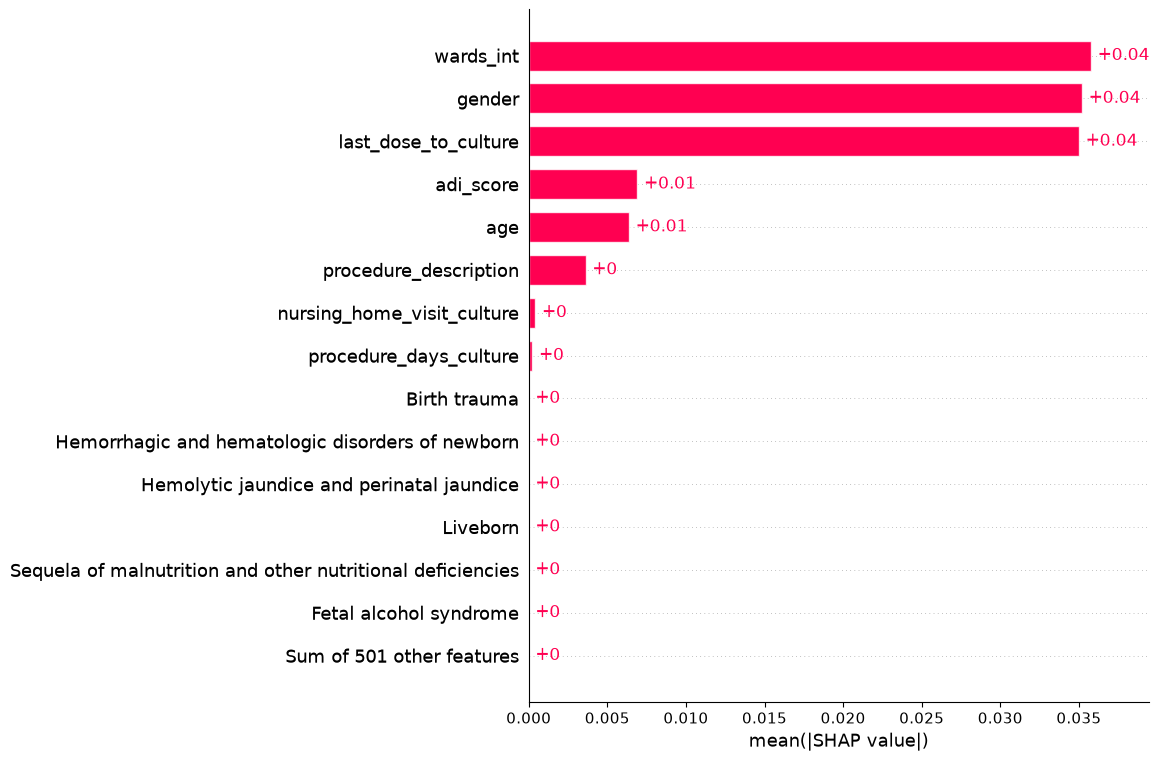

In [7]:
import shap
import pickle
import pandas as pd
DRUG = "AMC"
with open(f"CShapley/{DRUG}.sav", "rb") as file:
    shapley = pickle.load(file)
if "_reduced" in DRUG:
    df = pd.read_csv(f"dataset/by_antibiotic_12comorbdims/{DRUG.split("_")[0]}.csv")
    features = list(df.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant","Unnamed: 0"]).columns)
else:
    df = pd.read_csv(f"dataset/by_antibiotic/{DRUG}.csv")
    features = list(df.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant","Unnamed: 0",'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1']).columns)
shapley.feature_names = features
shap.plots.bar(shapley[:,:,1], max_display=15)